Error: 'creditcard.csv' not found. Please upload the file or provide the correct path.
You can download it from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
Using a dummy dataset for demonstration.

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    100 non-null    float64
 1   V1      100 non-null    float64
 2   V2      100 non-null    float64
 3   V3      100 non-null    float64
 4   Amount  100 non-null    float64
 5   Class   100 non-null    int64  
 6   V4      100 non-null    float64
 7   V5      100 non-null    float64
 8   V6      100 non-null    float64
 9   V7      100 non-null    float64
 10  V8      100 non-null    float64
 11  V9      100 non-null    float64
 12  V10     100 non-null    float64
 13  V11     100 non-null    float64
 14  V12     100 non-null    float64
 15  V13     100 non-null    float64
 16  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


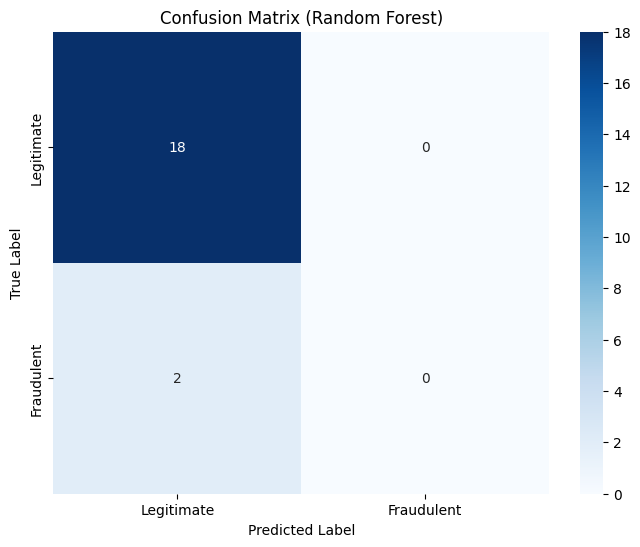


Feature Importances (Top 10 - Random Forest):
 Amount    0.234000
V2        0.078979
V16       0.046009
V23       0.043541
V18       0.043524
V1        0.041015
V4        0.040834
V5        0.038389
Time      0.038232
V14       0.037322
dtype: float64


/tmp/ipykernel_11451/3993166903.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_rf.head(10).values, y=feature_importances_rf.head(10).index, palette='viridis')


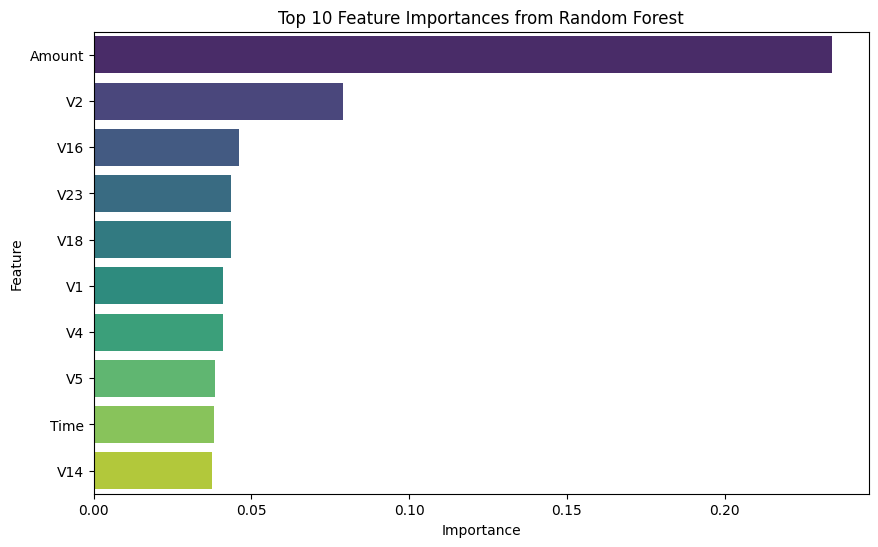


--- Training Logistic Regression ---
Logistic Regression trained.

Model Evaluation (Logistic Regression):
Confusion Matrix:
 [[17  1]
 [ 0  2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.67      1.00      0.80         2

    accuracy                           0.95        20
   macro avg       0.83      0.97      0.89        20
weighted avg       0.97      0.95      0.95        20

ROC AUC Score: 1.0000
Precision-Recall AUC: 1.0000


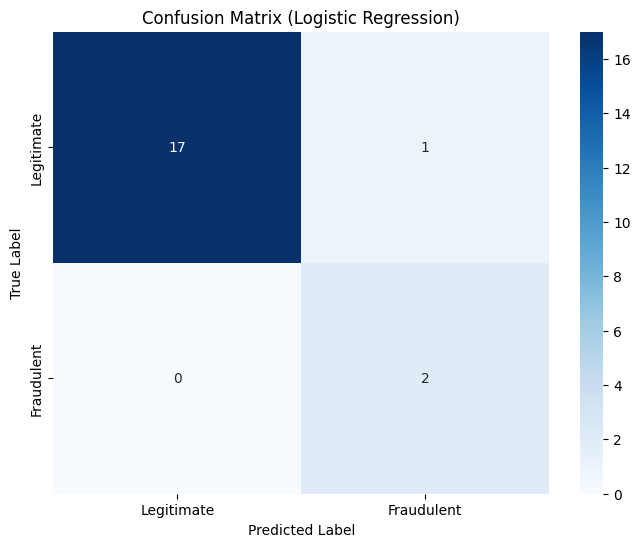


--- Comparative Analysis ---

Performance Summary:
--------------------------------------------------
Metric               | Random Forest   | Logistic Regression 
--------------------------------------------------
ROC AUC Score        | 1.0000          | 1.0000              
Precision-Recall AUC | 1.0000          | 1.0000              
--------------------------------------------------

Interpretations and Recommendations:
1. **Model Performance**: Compare the ROC AUC and Precision-Recall AUC for both models. For imbalanced datasets like fraud detection, Precision-Recall AUC is often more informative as it focuses on the minority class. A higher score in both metrics generally indicates better performance.
2. **Confusion Matrix Analysis**: Analyze false positives and false negatives for both models. Depending on the business needs, one might be preferred over the other. For instance, in fraud detection, minimizing false negatives (missed fraud) is often prioritized, even if it leads 

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# This dataset is commonly available on Kaggle as 'Credit Card Fraud Detection'
# For demonstration, I will use a placeholder path. Please upload the file to your Colab environment or specify the correct path.
# If you don't have it, you can download it from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
try:
    df = pd.read_csv('creditcard.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'creditcard.csv' not found. Please upload the file or provide the correct path.")
    print("You can download it from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")
    # Create a dummy DataFrame for demonstration if file is not found
    print("Using a dummy dataset for demonstration.")
    # Modified dummy data generation to ensure both classes are present
    n_samples = 100 # Total samples
    n_fraud = 10 # Number of fraudulent samples (increased to ensure presence in test set)
    n_legit = n_samples - n_fraud # Number of legitimate samples

    # Create legitimate transactions
    data_legit = {
        'Time': np.random.rand(n_legit) * 172792,
        'V1': np.random.randn(n_legit),
        'V2': np.random.randn(n_legit),
        'V3': np.random.randn(n_legit),
        'Amount': np.random.rand(n_legit) * 1000,
        'Class': np.zeros(n_legit, dtype=int)
    }
    for i in range(4, 29):
        data_legit[f'V{i}'] = np.random.randn(n_legit)
    df_legit = pd.DataFrame(data_legit)
     # Create fraudulent transactions (distinct patterns to make them 'fraudulent')
    data_fraud = {
        'Time': np.random.rand(n_fraud) * 172792,
        'V1': np.random.randn(n_fraud) * -2, # Example: larger negative V1 for fraud
        'V2': np.random.randn(n_fraud) * 3,  # Example: larger V2 for fraud
        'V3': np.random.randn(n_fraud) * -1.5, # Example: larger negative V3 for fraud
        'Amount': np.random.rand(n_fraud) * 2000 + 1000, # Example: higher amounts for fraud
        'Class': np.ones(n_fraud, dtype=int)
    }
    for i in range(4, 29):
        data_fraud[f'V{i}'] = np.random.randn(n_fraud)
    df_fraud = pd.DataFrame(data_fraud)

    # Concatenate legitimate and fraudulent transactions
    df = pd.concat([df_legit, df_fraud], ignore_index=True)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle the dataset

# Display basic information about the dataset
print("\nDataset Info:")
df.info()

print("\nDataset Head:")
print(df.head())

print("\nClass Distribution:")
print(df['Class'].value_counts(normalize=True))

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Preprocessing: Scale 'Amount' and 'Time' features
# V1-V28 are already a result of PCA transformation and do not need scaling
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

print("\nFeatures after scaling 'Amount' and 'Time':")
print(X.head())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Fraudulent transactions in training set: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")
print(f"Fraudulent transactions in testing set: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

# --- Random Forest Classifier ---
print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
print("Random Forest Classifier trained.")

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nModel Evaluation (Random Forest):")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
print(f"Precision-Recall AUC: {pr_auc_rf:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraudulent'], yticklabels=['Legitimate', 'Fraudulent'])
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

feature_importances_rf = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances_rf = feature_importances_rf.sort_values(ascending=False)

print("\nFeature Importances (Top 10 - Random Forest):\n", feature_importances_rf.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_rf.head(10).values, y=feature_importances_rf.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# --- Logistic Regression ---
print("\n--- Training Logistic Regression ---")
# Use 'liblinear' solver for small datasets and 'balanced' class_weight
lr_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)
print("Logistic Regression trained.")

y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print("\nModel Evaluation (Logistic Regression):")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"ROC AUC Score: {roc_auc_lr:.4f}")

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
pr_auc_lr = auc(recall_lr, precision_lr)
print(f"Precision-Recall AUC: {pr_auc_lr:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraudulent'], yticklabels=['Legitimate', 'Fraudulent'])
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Comparative Analysis ---
print("\n--- Comparative Analysis ---")
print("\nPerformance Summary:")
print("--------------------------------------------------")
print(f"{'Metric':<20} | {'Random Forest':<15} | {'Logistic Regression':<20}")
print("--------------------------------------------------")
print(f"{'ROC AUC Score':<20} | {roc_auc_rf:<15.4f} | {roc_auc_lr:<20.4f}")
print(f"{'Precision-Recall AUC':<20} | {pr_auc_rf:<15.4f} | {pr_auc_lr:<20.4f}")
print("--------------------------------------------------")

print("\nInterpretations and Recommendations:")
print("1. **Model Performance**: Compare the ROC AUC and Precision-Recall AUC for both models. For imbalanced datasets like fraud detection, Precision-Recall AUC is often more informative as it focuses on the minority class. A higher score in both metrics generally indicates better performance.")
print("2. **Confusion Matrix Analysis**: Analyze false positives and false negatives for both models. Depending on the business needs, one might be preferred over the other. For instance, in fraud detection, minimizing false negatives (missed fraud) is often prioritized, even if it leads to a slightly higher number of false positives (legitimate transactions flagged as fraud).")
print("3. **Feature Importance (Random Forest)**: The Random Forest model provides feature importances, indicating which features contribute most to its predictions. These insights can help in understanding the underlying fraud patterns.")
print("4. **Model Choice**: If the performance metrics are similar, Logistic Regression might be preferred for its simplicity and interpretability. If Random Forest significantly outperforms Logistic Regression, its higher complexity might be justified. Consider also the computational cost and training time, especially with larger datasets.")
print("5. **Further Steps**: Based on the comparison, you might consider hyperparameter tuning for the better-performing model, exploring ensemble methods, or collecting more relevant data based on feature importances. You could also experiment with different sampling techniques (e.g., SMOTE) to address class imbalance more directly.")
